In [9]:
!pip install requests matplotlib -q

import requests
import json
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Define the base URL for the PDF Figure Extractor service
BASE_URL = "http://localhost:5001/extract"

def display_random_figure(figure_names, output_directory):
    """Display a random figure from the provided list of figure names."""
    # Select a random figure
    random_figure = random.choice(figure_names)
    
    # Construct the full path to the image
    image_path = f"{output_directory}/{random_figure}"
    
    # Load and display the image
    img = mpimg.imread(image_path)
    plt.imshow(img)
    plt.axis('off')  # Hide axes
    plt.title(f"Figure: {random_figure}")
    plt.show()

output_dir = "data/output/figures"

In [4]:
def extract_from_local_pdf(pdf_path):
    """Extract figures from a local PDF file."""
    payload = {
        "source": pdf_path
    }
    response = requests.post(BASE_URL, headers={"Content-Type": "application/json"}, json=payload)
    return response.json()

def extract_from_url(pdf_url):
    """Extract figures from a PDF available at a URL."""
    payload = {
        "source": pdf_url
    }
    response = requests.post(BASE_URL, headers={"Content-Type": "application/json"}, json=payload)
    return response.json()

def batch_process_directory(pdf_directory, stat_file):
    """Batch process a directory of PDFs."""
    payload = {
        "source": pdf_directory,
        "stat_file": stat_file
    }
    response = requests.post(BASE_URL, headers={"Content-Type": "application/json"}, json=payload)
    return response.json()

In [20]:
# Example 1: Extract from Local PDF
local_pdf_path = "data/input/2406.13495v1.pdf"
print(f"Extracting from local PDF: {local_pdf_path}")
local_pdf_result = extract_from_local_pdf(local_pdf_path)
print(json.dumps(local_pdf_result, indent=2))

Extracting from local PDF: data/input/2406.13495v1.pdf
{
  "figures": [
    "2406.13495v1-Figure1-1.png",
    "2406.13495v1-Figure10-1.png",
    "2406.13495v1-Figure11-1.png",
    "2406.13495v1-Figure12-1.png",
    "2406.13495v1-Figure13-1.png",
    "2406.13495v1-Figure14-1.png",
    "2406.13495v1-Figure15-1.png",
    "2406.13495v1-Figure16-1.png",
    "2406.13495v1-Figure17-1.png",
    "2406.13495v1-Figure2-1.png",
    "2406.13495v1-Figure3-1.png",
    "2406.13495v1-Figure4-1.png",
    "2406.13495v1-Figure5-1.png",
    "2406.13495v1-Figure6-1.png",
    "2406.13495v1-Figure7-1.png",
    "2406.13495v1-Figure8-1.png",
    "2406.13495v1-Figure9-1.png",
    "2406.13495v1-Table1-1.png",
    "2406.13495v1-Table10-1.png",
    "2406.13495v1-Table11-1.png",
    "2406.13495v1-Table12-1.png",
    "2406.13495v1-Table13-1.png",
    "2406.13495v1-Table14-1.png",
    "2406.13495v1-Table15-1.png",
    "2406.13495v1-Table16-1.png",
    "2406.13495v1-Table17-1.png",
    "2406.13495v1-Table2-1.png",
    

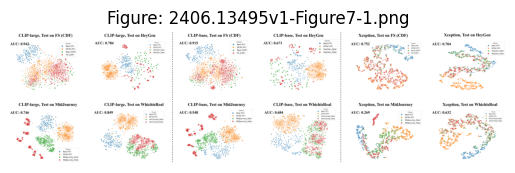

In [23]:
figure_names = local_pdf_result["figures"]
display_random_figure(figure_names, output_dir)

- Images saved in the data/output folder are higher quality 300 dpi. 

In [6]:
# Example 2: Extract from URL
pdf_url = "https://arxiv.org/pdf/2307.03550.pdf"
print(f"\nExtracting from URL: {pdf_url}")
url_result = extract_from_url(pdf_url)
print(json.dumps(url_result, indent=2))


Extracting from URL: https://arxiv.org/pdf/2307.03550.pdf
{
  "figures": [
    "6a329a86-6e96-454d-8de5-9edae66ce347-Figure1-1.png",
    "6a329a86-6e96-454d-8de5-9edae66ce347-Table1-1.png",
    "6a329a86-6e96-454d-8de5-9edae66ce347-Table2-1.png",
    "6a329a86-6e96-454d-8de5-9edae66ce347-Table3-1.png",
    "6a329a86-6e96-454d-8de5-9edae66ce347-Table4-1.png",
    "6a329a86-6e96-454d-8de5-9edae66ce347-Table5-1.png",
    "6a329a86-6e96-454d-8de5-9edae66ce347-Table6-1.png",
    "6a329a86-6e96-454d-8de5-9edae66ce347-Table7-1.png",
    "6a329a86-6e96-454d-8de5-9edae66ce347-Table8-1.png",
    "6a329a86-6e96-454d-8de5-9edae66ce347-Table9-1.png"
  ],
  "message": "Figures extracted successfully.",
  "metadata": [],
  "success": true,
  "totalFigures": 10
}


In [7]:
# Example 3: Batch Process Directory
pdf_directory = "data/input/"
stat_file = "data/stat.json"
print(f"\nBatch processing directory: {pdf_directory}")
batch_result = batch_process_directory(pdf_directory, stat_file)
print(json.dumps(batch_result, indent=2))


Batch processing directory: data/input/
{
  "message": "Batch processing completed successfully.",
  "success": true
}
